# W02 RF Benchmark

**Platform:** Aido Rover  
**Seed:** 42  
**Sampling rate:** 10 Hz


In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

DATA_DIR = Path('../data')
TEMP_DIR = DATA_DIR / 'temp'
SEED     = 42


# ── Load raw (pre-scale/PCA) arrays from W02_Preprocessing_Pipeline.ipynb ──────────
X_tr_raw    = np.load(TEMP_DIR / 'X_tr_raw.npy')
X_va_raw    = np.load(TEMP_DIR / 'X_va_raw.npy')
X_te_raw    = np.load(TEMP_DIR / 'X_te_raw.npy')
y_tr_s      = np.load(TEMP_DIR / 'y_tr_s.npy')
y_va_s      = np.load(TEMP_DIR / 'y_va_s.npy')
y_te_s      = np.load(TEMP_DIR / 'y_te_s.npy')
block_id_tr = np.load(TEMP_DIR / 'block_id_tr.npy')   # train-row block ids, for GroupKFold CV

split_df = pd.read_csv(DATA_DIR / 'rover_stratified_block_split.csv')
fold_role = split_df.drop_duplicates('fold_id').set_index('fold_id')['split'].to_dict()
print('Fold -> role:')
for f in sorted(fold_role):
    print(f'  fold {f}: {fold_role[f]}')
print()
print('Canonical split (raw 40-D feature space, pre-transform)')
for name, y in [('train', y_tr_s), ('val', y_va_s), ('test', y_te_s)]:
    print(f'  {name:5s}: {len(y):>6,}  |  normal={(y==0).sum():,}  '
          f'anomaly={(y==1).sum():,}  ({(y==1).mean()*100:.1f}%)')


Fold -> role:
  fold 0: train
  fold 1: val
  fold 2: test
  fold 3: train
  fold 4: train
  fold 5: train
  fold 6: train

Canonical split (raw 40-D feature space, pre-transform)
  train:  9,734  |  normal=8,134  anomaly=1,600  (16.4%)
  val  :  2,215  |  normal=1,861  anomaly=354  (16.0%)
  test :  1,901  |  normal=1,597  anomaly=304  (16.0%)


### RF Training

`StandardScaler → PCA(0.95) → RandomForestClassifier` as a single pipeline, so every
`GridSearchCV` fold refits the scaler and PCA on only that fold's own training rows — same discipline the 7-fold rotation check applies. Grid search over `n_estimators ∈ {50, 100, 200}` × `max_depth ∈ {None, 5, 10, 20}` (12 combos), `StratifiedGroupKFold` 5-fold CV (`groups=block_id_tr`), F1 scoring, `class_weight='balanced'`.

The deployed model uses **all PCA components retained at 95% variance** (19).

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              roc_curve, f1_score)

# ── Grid search over a single Pipeline (scaler+PCA refit per CV fold, no leakage into CV) ──
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=SEED)),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=1)),
])
param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 5, 10, 20],
}
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
gs = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0)

t_start = time.perf_counter()
gs.fit(X_tr_raw, y_tr_s, groups=block_id_tr)
train_time_s = time.perf_counter() - t_start

best_pipeline = gs.best_estimator_
best_params   = {k.replace('rf__', ''): v for k, v in gs.best_params_.items()}
n_components_retained = best_pipeline.named_steps['pca'].n_components_

print(f'Best hyperparameters : {best_params}')
print(f'PCA components (95% var, refit on full train) : {n_components_retained}')
print(f'CV best F1           : {gs.best_score_:.4f}')
print(f'Train time           : {train_time_s:.2f} s')

# ── Inference / 1,000 samples (single timing pass) ───────────────────────
x_infer_1k = X_te_raw[:1000]
_t0 = time.perf_counter()
_ = best_pipeline.predict(x_infer_1k)
infer_1k_ms = (time.perf_counter() - _t0) * 1000
print(f'Inference / 1,000 samples : {infer_1k_ms:.2f} ms')

# ── Predicted probabilities + AUC-ROC (threshold-free, feeds both the threshold
# tuning step and the evaluation step below) ────────────────────────────────
y_tr_proba = best_pipeline.predict_proba(X_tr_raw)[:, 1]
y_va_proba = best_pipeline.predict_proba(X_va_raw)[:, 1]
y_te_proba = best_pipeline.predict_proba(X_te_raw)[:, 1]
auc_tr = roc_auc_score(y_tr_s, y_tr_proba)
auc_va = roc_auc_score(y_va_s, y_va_proba)
auc_te = roc_auc_score(y_te_s, y_te_proba)
print(f'\nAUC-ROC  train={auc_tr:.4f}  val={auc_va:.4f}  test={auc_te:.4f}')


Best hyperparameters : {'max_depth': 10, 'n_estimators': 200}
PCA components (95% var, refit on full train) : 19
CV best F1           : 0.7494
Train time           : 10.29 s
Inference / 1,000 samples : 14.79 ms

AUC-ROC  train=0.9997  val=0.9730  test=0.9668


### Validation-Tuned Decision Threshold

`predict_proba`'s default 0.5 cutoff is an arbitrary convention. Sweeping the threshold on **validation** to maximise F1, then applying that fixed threshold once to test:


In [10]:
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0.1, 0.9, 81)
va_f1_by_t = [f1_score(y_va_s, y_va_proba >= t) for t in thresholds]
tuned_threshold = thresholds[int(np.argmax(va_f1_by_t))]

print('── Threshold tuning (selected on val, applied to test) ──────────────')
for t, tag in [(0.5, 'default'), (tuned_threshold, 'val-tuned')]:
    pred = y_te_proba >= t
    print(f'  {tag:10s} (t={t:.2f}): test F1={f1_score(y_te_s, pred):.4f}  '
          f'precision={precision_score(y_te_s, pred):.4f}  recall={recall_score(y_te_s, pred):.4f}')
print(f'  test AUC-ROC (threshold-free): {auc_te:.4f}')


── Threshold tuning (selected on val, applied to test) ──────────────
  default    (t=0.50): test F1=0.7350  precision=0.7651  recall=0.7072
  val-tuned  (t=0.49): test F1=0.7359  precision=0.7633  recall=0.7105
  test AUC-ROC (threshold-free): 0.9668


### Evaluation

Train/val/test classification reports, confusion matrices and ROC curves, evaluated at
the val-tuned decision threshold.


── Train ──
              precision    recall  f1-score   support

      Normal     1.0000    0.9650    0.9822      8134
     Anomaly     0.8488    1.0000    0.9182      1600

    accuracy                         0.9707      9734
   macro avg     0.9244    0.9825    0.9502      9734
weighted avg     0.9751    0.9707    0.9717      9734

AUC-ROC : 0.9997

── Validation ──
              precision    recall  f1-score   support

      Normal     0.9725    0.9511    0.9617      1861
     Anomaly     0.7696    0.8588    0.8117       354

    accuracy                         0.9363      2215
   macro avg     0.8711    0.9049    0.8867      2215
weighted avg     0.9401    0.9363    0.9377      2215

AUC-ROC : 0.9730

── Test ──
              precision    recall  f1-score   support

      Normal     0.9456    0.9580    0.9518      1597
     Anomaly     0.7633    0.7105    0.7359       304

    accuracy                         0.9185      1901
   macro avg     0.8544    0.8343    0.8439      19

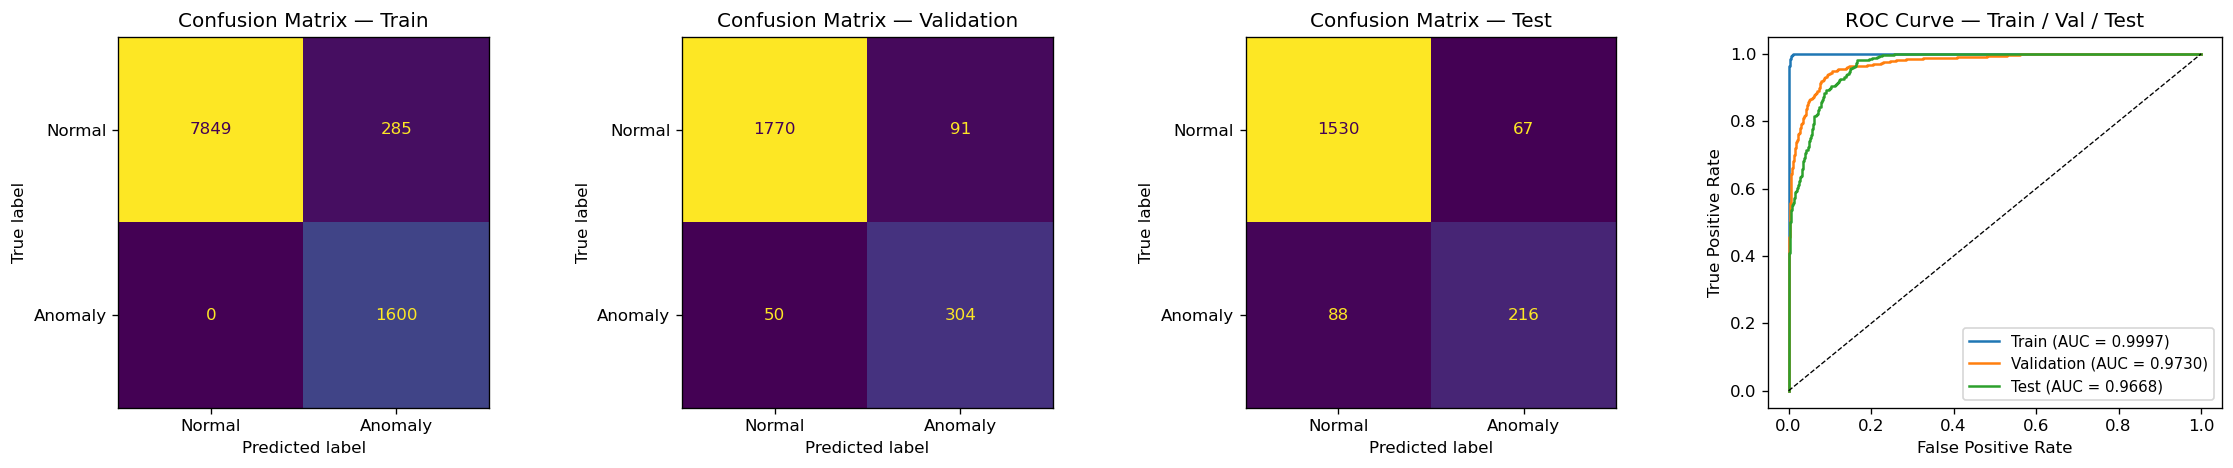

In [11]:
y_tr_pred = (y_tr_proba >= tuned_threshold).astype(int)
y_va_pred = (y_va_proba >= tuned_threshold).astype(int)
y_te_pred = (y_te_proba >= tuned_threshold).astype(int)

print('\n── Train ──')
print(classification_report(y_tr_s, y_tr_pred, target_names=['Normal', 'Anomaly'], digits=4))
print(f'AUC-ROC : {auc_tr:.4f}')

print('\n── Validation ──')
print(classification_report(y_va_s, y_va_pred, target_names=['Normal', 'Anomaly'], digits=4))
print(f'AUC-ROC : {auc_va:.4f}')

print('\n── Test ──')
print(classification_report(y_te_s, y_te_pred, target_names=['Normal', 'Anomaly'], digits=4))
print(f'AUC-ROC : {auc_te:.4f}')

test_f1_score = f1_score(y_te_s, y_te_pred)

# ── Confusion matrices (train/val/test) + ROC curves (all three overlaid) ──
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

fig, axes = plt.subplots(1, 4, figsize=(19, 4))

ConfusionMatrixDisplay(confusion_matrix(y_tr_s, y_tr_pred),
                       display_labels=['Normal', 'Anomaly']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Train')

ConfusionMatrixDisplay(confusion_matrix(y_va_s, y_va_pred),
                       display_labels=['Normal', 'Anomaly']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix — Validation')

ConfusionMatrixDisplay(confusion_matrix(y_te_s, y_te_pred),
                       display_labels=['Normal', 'Anomaly']).plot(ax=axes[2], colorbar=False)
axes[2].set_title('Confusion Matrix — Test')

for y_true, y_proba, auc, label in [(y_tr_s, y_tr_proba, auc_tr, 'Train'),
                                     (y_va_s, y_va_proba, auc_va, 'Validation'),
                                     (y_te_s, y_te_proba, auc_te, 'Test')]:
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    axes[3].plot(fpr, tpr, lw=1.5, label=f'{label} (AUC = {auc:.4f})')
axes[3].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[3].set_xlabel('False Positive Rate')
axes[3].set_ylabel('True Positive Rate')
axes[3].set_title('ROC Curve — Train / Val / Test')
axes[3].legend(fontsize=9)

plt.tight_layout()
plt.show()


### 7-Fold Block-Rotation Robustness Check

The canonical split is still one draw from 23 blocks — with only 72 fault
events total, a single test fold's F1 reflects real sampling variance. Rotating which fold plays test/val —
using the `fold_id` column persisted in `data/rover_stratified_block_split.csv`, the same partition the
canonical roles come from — with the same `Pipeline(scaler, PCA, RF)` and hyperparameters (refit per
rotation on that rotation's own train fold) gives a mean ± std across all 7 possible test folds. One caveat
on scope: hyperparameters stay fixed at the canonical-fold grid-search winner across all rotations (no
per-fold re-tuning), so this measures evaluation variance under a fixed configuration, not full nested-CV
pipeline variance, and likely slightly understates what per-fold re-tuning could reach on each rotation.


In [12]:
X_all_raw    = np.load(TEMP_DIR / 'X_all_raw.npy')
y_all        = np.load(TEMP_DIR / 'y_all.npy')
fold_of_row  = np.load(TEMP_DIR / 'fold_id_all.npy')   # canonical fold ids from rover_stratified_block_split.csv

CANONICAL_TEST_FOLD = int(split_df.loc[split_df['split'] == 'test', 'fold_id'].iloc[0])
CANONICAL_VAL_FOLD  = int(split_df.loc[split_df['split'] == 'val',  'fold_id'].iloc[0])

rot_f1_default, rot_f1_tuned, rot_auc, rot_test_rate, rot_fold_id = [], [], [], [], []
for k in range(7):
    te_mask = fold_of_row == k
    va_mask = fold_of_row == (k + 1) % 7
    tr_mask = ~(te_mask | va_mask)

    rot_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95, random_state=SEED)),
        ('rf', RandomForestClassifier(**best_params, class_weight='balanced', random_state=SEED, n_jobs=-1)),
    ])
    rot_pipe.fit(X_all_raw[tr_mask], y_all[tr_mask])
    p_va, p_te = rot_pipe.predict_proba(X_all_raw[va_mask])[:, 1], rot_pipe.predict_proba(X_all_raw[te_mask])[:, 1]
    t_k = thresholds[int(np.argmax([f1_score(y_all[va_mask], p_va >= t) for t in thresholds]))]

    rot_f1_default.append(f1_score(y_all[te_mask], p_te >= 0.5))
    rot_f1_tuned.append(f1_score(y_all[te_mask], p_te >= t_k))
    rot_auc.append(roc_auc_score(y_all[te_mask], p_te))
    rot_test_rate.append(y_all[te_mask].mean())
    rot_fold_id.append(k)
    marker = '  <- canonical test fold' if k == CANONICAL_TEST_FOLD else ('  <- canonical val fold' if k == CANONICAL_VAL_FOLD else '')
    print(f'  fold {k}: test anomaly rate={rot_test_rate[-1]*100:5.1f}%  F1@0.5={rot_f1_default[-1]:.4f}  '
          f'F1@tuned(t={t_k:.2f})={rot_f1_tuned[-1]:.4f}  AUC={rot_auc[-1]:.4f}{marker}')

print(f'\n  F1@0.5   : mean={np.mean(rot_f1_default):.4f} +/- {np.std(rot_f1_default):.4f}  '
      f'range [{min(rot_f1_default):.3f}, {max(rot_f1_default):.3f}]')
print(f'  F1@tuned : mean={np.mean(rot_f1_tuned):.4f} +/- {np.std(rot_f1_tuned):.4f}  '
      f'range [{min(rot_f1_tuned):.3f}, {max(rot_f1_tuned):.3f}]')
print(f'  AUC      : mean={np.mean(rot_auc):.4f} +/- {np.std(rot_auc):.4f}  '
      f'range [{min(rot_auc):.3f}, {max(rot_auc):.3f}]')

canonical_idx = rot_fold_id.index(CANONICAL_TEST_FOLD)
canonical_f1 = rot_f1_default[canonical_idx]
percentile = int(100 * (np.array(rot_f1_default) <= canonical_f1).mean())
print(f'\n  Canonical single-fold test F1 ({canonical_f1:.4f}) percentile within the 7-fold '
      f'distribution: {percentile}th')


  fold 0: test anomaly rate= 17.8%  F1@0.5=0.6846  F1@tuned(t=0.55)=0.7179  AUC=0.9510
  fold 1: test anomaly rate= 16.0%  F1@0.5=0.8097  F1@tuned(t=0.40)=0.7804  AUC=0.9730  <- canonical val fold
  fold 2: test anomaly rate= 16.0%  F1@0.5=0.7544  F1@tuned(t=0.39)=0.7622  AUC=0.9655  <- canonical test fold
  fold 3: test anomaly rate= 15.7%  F1@0.5=0.6883  F1@tuned(t=0.46)=0.6971  AUC=0.9531
  fold 4: test anomaly rate= 15.0%  F1@0.5=0.8509  F1@tuned(t=0.61)=0.8447  AUC=0.9707
  fold 5: test anomaly rate= 13.8%  F1@0.5=0.7067  F1@tuned(t=0.49)=0.7027  AUC=0.9537
  fold 6: test anomaly rate= 20.3%  F1@0.5=0.7860  F1@tuned(t=0.66)=0.7396  AUC=0.9495

  F1@0.5   : mean=0.7544 +/- 0.0596  range [0.685, 0.851]
  F1@tuned : mean=0.7492 +/- 0.0481  range [0.697, 0.845]
  AUC      : mean=0.9595 +/- 0.0092  range [0.950, 0.973]

  Canonical single-fold test F1 (0.7544) percentile within the 7-fold distribution: 57th


### Latency Benchmarking

Latency benchmarking with timeit (mean of 100 repetitions), test F1 and latency under 100ms.
Aido Rover real-time constraint: single-sample inference under 100 ms for a 10 Hz stream. The timed
pipeline includes the scaler and PCA transform, not just the RF's own predict — this is the true
per-sample latency a deployed instance would see.


In [13]:
import timeit

N_REPS        = 100
CONSTRAINT_MS = 100.0          # Aido Rover 10 Hz real-time limit
x_single      = X_te_raw[0:1]
x_batch_1k    = X_te_raw[:1000]

# ── Single-sample latency (timeit, 100 reps) ───────────────────────────────
single_total  = timeit.timeit(lambda: best_pipeline.predict(x_single), number=N_REPS)
single_ms     = (single_total / N_REPS) * 1000

# ── 1,000-sample batch latency (timeit, 100 reps) ─────────────────────────
batch_total   = timeit.timeit(lambda: best_pipeline.predict(x_batch_1k), number=N_REPS)
batch_1k_ms   = (batch_total / N_REPS) * 1000
per_sample_ms = batch_1k_ms / 1000

meets_rt = single_ms < CONSTRAINT_MS

print('── Latency Benchmark ──────────────────')
print(f'  Single-sample inference  : {single_ms:.3f} ms')
print(f'  1,000-sample batch       : {batch_1k_ms:.2f} ms  '
      f'({per_sample_ms:.4f} ms per sample in batch)')
print(f'  Test F1 (anomaly, tuned threshold) : {test_f1_score:.4f}')
print()
print(f'  Real-time constraint     : < {CONSTRAINT_MS:.0f} ms per sample @ 10 Hz')
print(f'  Single-sample result     : {single_ms:.3f} ms   '
      f'{"PASS" if meets_rt else "FAIL"}')
if meets_rt:
    print(f'  Deployment verdict: RF {best_params} ({n_components_retained} PCA components) '
          f'meets the constraint at {single_ms:.3f} ms per sample')
else:
    print()
    print(f'  Deployment verdict: RF {best_params} does NOT meet the 10 Hz constraint')
    print(f'  ({single_ms:.2f} ms > {CONSTRAINT_MS:.0f} ms). Reduce n_estimators or cap max_depth.')


── Latency Benchmark ──────────────────
  Single-sample inference  : 7.912 ms
  1,000-sample batch       : 14.15 ms  (0.0141 ms per sample in batch)
  Test F1 (anomaly, tuned threshold) : 0.7359

  Real-time constraint     : < 100 ms per sample @ 10 Hz
  Single-sample result     : 7.912 ms   PASS
  Deployment verdict: RF {'max_depth': 10, 'n_estimators': 200} (19 PCA components) meets the constraint at 7.912 ms per sample
